# A tutorial for NuQuLib 

In this tutorial, we explore key functionalities of NuQuLib, a quantum computing library for simulating nuclear systems. We cover the following topics:

1. Hamiltonian mapping  
   - a. Jordan–Wigner mapping of nuclear Hamiltonians  
   - b. Pairing Hamiltonian  
   - c. Comparison with chemical Hamiltonians  
2. Variational Quantum Eigensolver (VQE) example  
3. (Early-)FTQC algorithm example: QPE for small systems

In [1]:
from scipy.special import comb
import seaborn as sns
import re
from nuqulib import *

def cnuc(nuc): # convert "2H" to "$^{2}$H"
    A = re.findall(r'\d+', nuc)
    element = nuc.replace(A[0], "")
    return f"$^{{{A[0]}}}${element}"

# My color palette
cols = sns.color_palette("deep", 10)
cols[0], cols[2] = cols[2], cols[0] 
cols[1], cols[3] = cols[3], cols[1] 

root_dir = "./"
int_file_path = root_dir + "tests/interaction_file/"
device_type = "CPU" # "CPU" or "GPU"

/Users/sotair/venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


## 1. Hamiltonian mapping

### a) Jordan–Wigner mapping of nuclear Hamiltonians

In this section, we demonstrate the usage of `NuQuLib` for mapping shell-model Hamiltonians.

First, we read the `ckpot` effective interaction for the 0p shell (p1/2 and p3/2 orbitals on top of a 4He core) and map it to a qubit Hamiltonian using the Jordan–Wigner transformation.

NuQuLib can read interaction files for NN and 3N interactions, for example in `snt` format (`kshell.snt` in NuHamil).

You can (partially) check whether the mapping is correct by comparing the ground-state energy of fully occupied systems in the specified model space.

Below, we confirm correct results for both valence spaces (p, sd) and a few No-core shell model spaces.

#### valence space

We consider the following fully occupied systems in valence-shell model spaces:

- 16O in the p shell  
- 40Ca in the sd shell  



In [2]:
fns = ["ckpot.snt", "usdb.snt"]
ZNs = [ (8, 8), (20, 20) ]

for idx in range(len(fns)):
    filename_snt = int_file_path + fns[idx]
    print("filename_snt:", filename_snt)
    Z, N = ZNs[idx]
    hamil = Hamiltonian(filename_snt, Z, N)

    mapping_method = "JordanWigner"
    hamil.get_mscheme_H(opform=True)
    H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
    H_1b = H_1b_p + H_1b_n

    n_qubits = hamil.n_qubits
    qc = QuantumCircuit(n_qubits)
    qc.x(range(n_qubits))  # prepare all qubits in |1> state

    # measurement of Hamiltonian
    estimator = StatevectorEstimator()
    job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn)])
    results = job.result()
    E_1b, E_pp, E_nn, E_pn = [ results[i].data.evs for i in range(len(results))]
    E_total = E_1b + E_pp + E_nn + E_pn 
    print("Etot", E_total, "E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn)


filename_snt: ./tests/interaction_file/ckpot.snt


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...



100%|██████████| 262/262 [00:00<00:00, 4798723.35it/s]


Removing redundant terms... len= 3376


...

# of H_m terms, 1b: 24, 2b pp: 620, nn: 620, pn: 3618 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...


100%|██████████| 2884/2884 [00:00<00:00, 8453090.66it/s]


Removing redundant terms... len= 41472


41472it [00:00, 254694.90it/s]


Finally, len =>  9513
Etot -279.9607012333838 E_1b:  -43.04640000000002 <pp> -15.600464041796151 <nn> -15.600464041796151 <pn> -205.71337314979147


#### NCSM (no-core shell model) space

For nucleon-nucleon (NN) interaction, we use EM500 with SRG (1.8 fm\(^{-1}\) cutoff), in an harmonic oscillator (HO) basis with hw = 20 MeV and emax = 1. For three-nucleon (3N) interaction, we use the local-nonlocal (lnl) interaction.
Note that one can use [NuHamil code](https://github.com/Takayuki-Miyagi/NuHamil-public) to generate the NN and 3N interactions based on chiral effective field theory (EFT).

Note that results depend on the chosen interaction and Hamiltonian-generation settings.  
With a certain setting, the ground-state energy of \({}^{16}\mathrm{O}\) is expected to be \(-131.83565\) MeV.


In [3]:
emax = 1
filename_snt = int_file_path + "TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
Z = proton_number  = N = neutron_number = 8

hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, verbose=False, emax_truncate=emax,
                    e3max=emax, fn_3NF=fn_3NF)
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
H_1b = H_1b_p + H_1b_n

Hamil_NCSM_NN = H_1b + H_pp + H_nn + H_pn
hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NCSM_NN3NF = Hamil_NCSM_NN + H_3b

n_qubits = hamil.n_qubits
qc = QuantumCircuit(n_qubits)
qc.x(range(n_qubits))  # prepare all qubits in |1> state

# measurement of Hamiltonian
estimator = StatevectorEstimator()
job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn), (qc, H_3b)])
results = job.result()
E_1b, E_pp, E_nn, E_pn, E_3n = [ results[i].data.evs for i in range(len(results))]
E_total = E_1b + E_pp + E_nn + E_pn + E_3n
print("Etot", E_total, "E(NN)", E_1b + E_pp + E_nn + E_pn)
print("E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn, "<3b>", E_3n)

print("Example of NN+3NF terms:")
print(H_3b[:100:20])

Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 9258.85it/s]


Total number of 3NF matrix elements in M-scheme 15984


100%|██████████| 15984/15984 [00:00<00:00, 700160.36it/s]

# of H_m terms, 1b: 16, 2b pp: 83, nn: 83, pn: 456 v3b 2128
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...


...

100%|██████████| 408/408 [00:00<00:00, 6070.10it/s]


Total number of 3NF matrix elements in M-scheme 15984


100%|██████████| 2128/2128 [00:00<00:00, 5103189.77it/s]

Encoding 3NF in Jordan-Wigner mapping... # of 3NF terms: 2128


Removing redundant terms... len= 53632 => 2339
3NF mapping done in 0.60 sec.  3884.74 terms/sec
Etot -131.83565105910458 E(NN) -148.36878574000022
E_1b:  337.5 <pp> -53.04027524000001 <nn> -70.00286417999999 <pn> -362.8256463200002 <3b> 16.53313468089563
Example of NN+3NF terms:
SparsePauliOp(['IIIIIIIIIIIIIIII', 'IIIIIIYXIIIIXYII', 'IIIIIIYYIIIIYYZI', 'IIIIIXXIIIIIIYYI', 'IIIIXZXIIIIIIYIY'],
              coeffs=[ 2.06664184+0.j, -0.03543338+0.j, -0.01771669+0.j, -0.03105602+0.j,
 -0.02241239+0.j])


### b) Pairing Hamiltonian

The pairing Hamiltonian is a simplified model of nuclear interaction (or BCS-type pairing).  
A Hamiltonian with global pairing interaction is given by

$$
H = \sum_{i} \epsilon_i a_i^{\dagger} a_i - \frac{g}{4} \sum{i,j} a_i^{\dagger} a_{\bar{i}}^{\dagger} a_{\bar{j}} a_j
$$

where \(a_i^\dagger\) and \(a_i\) are creation and annihilation operators for a nucleon in orbital \(i\), \(\epsilon_i\) is the single-particle energy, \(g\) is the pairing strength, and \(\bar{i}\) denotes the time-reversed orbital of \(i\).


In [4]:
Norb = 12
Nocc = 6
gval = 0.33
hamil = PairingHamiltonian(Norb, Nocc, gval)
Hamil_Pairing = hamil.encoding()

# Make a time evolution operator U = exp(-iHt)
delta_t = 0.1
Unitary_P = PauliEvolutionGate(Hamil_Pairing, delta_t, synthesis=SuzukiTrotter(order=1,reps=1))
print("U:", Unitary_P)

# Make a quantum circuit (1 ancilla + target qubits)
qc = QuantumCircuit(Norb+1)
Unitary_P = Unitary_P.control(1)
qc.append(Unitary_P, range(Norb+1))
qc = qc.decompose(reps=5)
print("# of gates, raw circuit:", qc.count_ops())

U: Instruction(name='PauliEvolution', num_qubits=12, num_clbits=0, params=[0.1])
# of gates, raw circuit: OrderedDict({'u': 1345, 'cx': 552})


### c) Chemical Hamiltonians

According to the PennyLane documentation [here](https://docs.pennylane.ai/en/stable/introduction/chemistry.html), the `qchem` module provides molecular Hamiltonians.

You can specify a molecule by its symbols and geometry, and generate its Hamiltonian with `qml.qchem.molecular_hamiltonian`.

Similarly, Qiskit provides molecular Hamiltonians through modules such as `qiskit_nature`.

In [5]:
symbols = ["Li", "H"]
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 2.969280527]])
molecule = qml.qchem.Molecule(symbols, geometry)
H, qubits = qml.qchem.molecular_hamiltonian(
    molecule,
    active_electrons=2,
    active_orbitals=5,
)
def circuit(params):
    qml.ApproxTimeEvolution(H, time=0.1, n=1)
    return [qml.expval(qml.PauliZ(i)) for i in range(qubits)]

dev = qml.device("default.qubit", wires=qubits)
params = np.random.rand(qubits)
compiled_qnode = qml.compile(
    qml.QNode(circuit, device=dev),
    basis_set=["CNOT", "RX", "RY", "RZ"])

spec = qml.specs(compiled_qnode)(params)

print("qubits:", qubits, "Gates:", dict(spec["resources"].gate_types))

qubits: 10 Gates: {'RZ': 1437, 'RX': 1186, 'CNOT': 2356}


## 2. Variational Quantum Eigensolver (VQE)

Many VQE implementations are available in quantum computing libraries (e.g., Qiskit and PennyLane), including unitary coupled-cluster (UCC) ansätze.

Here, we show a VQE example using the pair unitary coupled-cluster (pUCCD) ansatz adopted in the following paper:

S. Yoshida, T. Sato, T. Ogata, M. Kimura: [Phys. Rev. Research 8, 013134 (2026)](https://doi.org/10.1103/td9s-z7my)

NuQuLib provides fermionic representations of nuclear Hamiltonians, but direct use in VQE can be cumbersome, especially for NISQ-oriented workflows.  
Instead, we use the hard-core boson (HCB) mapping, which captures essential pairing correlations and is easier to implement on quantum hardware.

Below, we optimize the pUCCD ansatz for valence systems with even-number neutrons to estimate their ground state energies, comparing results with exact diagonalization to verify accuracy.

For valence two-neutron systems, ground-state energies are equivalent between fermionic and HCB representations, and the pUCCD ansatz can reach the exact value.

6He

/Users/sotair/venv/lib/python3.12/site-packages/pennylane_lightning/lightning_base/_serialize.py:364: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs = np.array(coeffs).astype(self.rtype)


   E_FCI: -3.90981   Egs(6He; DOCI: -3.9098127922477905
# of parameters: 2  Nq_C_Nocc-1: 2
Params_opt:      -1.328457   1.798637
E_opt(pUCCD):          -3.909812792248 error (to DOCI)  8.88e-16 ( 0.000%)

18O   E_FCI: -11.93179   Egs(18O; DOCI: -11.931788760722092
# of parameters: 5  Nq_C_Nocc-1: 5
Params_opt:       1.067169  -1.263958   1.642946  -0.674698   0.716758
E_opt(pUCCD):         -11.931788760722 error (to DOCI)  0.00e+00 ( 0.000%)

20O   E_FCI: -23.63209   Egs(20O; DOCI: -23.146144774823366
# of parameters: 8  Nq_C_Nocc-1: 14
Params_opt:       4.709437  -1.783432   0.757648  -0.354354   7.159967  -1.029057   2.316676  -1.085312
E_opt(pUCCD):         -23.005955850100 error (to DOCI)  1.40e-01 ( 0.606%)

42Ca   E_FCI: -19.73368   Egs(42Ca; DOCI: -19.733675401085186
# of parameters: 9  Nq_C_Nocc-1: 9
Params_opt:      -1.031140   1.204976  -4.766289   8.773848   0.689627  -0.734740   0.790070  -4.857757   8.370531
E_opt(pUCCD):         -19.733675401085 error (to DOCI) -1.07e-14 

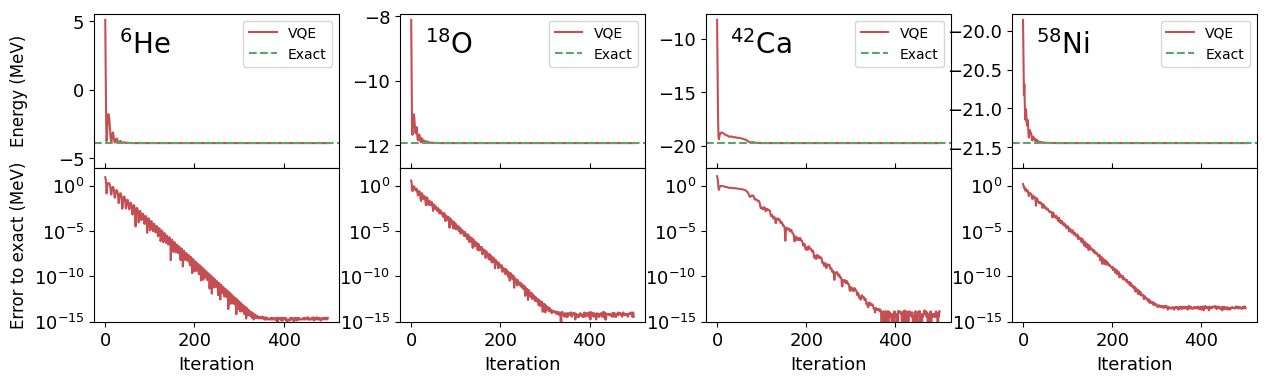

In [6]:
modelspace = {"p": {"msnt": "ckpot.msnt", 
                    "Acore":4, "Zcore":2, "Ncore":2, "pow_A": 1.0, "massop": 0,
                    "Nrange": range(4, 8, 2), "E_FCI": (-3.90981, -3.12306)},
              "sd": {"msnt": "usdb.msnt", 
                     "Acore":16, "Zcore":8, "Ncore":8, "pow_A": -0.3, "massop": 1,
                     "Nrange": range(10, 20, 2), "E_FCI": (-11.93179, -23.63209, -34.49787, -41.22531, -40.86881)},
              "pf": {"msnt": "gxpf1a.msnt", 
                     "Acore":40, "Zcore":20, "Ncore":20, "pow_A": -0.3, "massop": 1,
                     "Nrange": range(22, 40, 2), "E_FCI": (-19.73368, -38.67473, -56.66694, -73.66176, -85.05498, -95.36020, -102.63195, -104.58870, -106.66636)},
              "j45": {"msnt": "jun45.msnt",
                      "Acore": 56, "Zcore": 28, "Ncore": 28, "pow_A": -0.3, "massop": 1,
                      "Nrange": range(30, 50, 2), "E_FCI": (-21.44661, -41.27554, -59.60246, -76.44392, -91.94111, -106.13970, -119.03359, -130.92996, -141.93171, -152.10281)}}

Egs_FCI_dict = {}
for ms, subdict in modelspace.items():
    Zcore = subdict["Zcore"]
    Ncore = subdict["Ncore"]
    Z = 0 # assuming valence neutron systems
    for (idx_N, N) in enumerate(subdict["Nrange"]):
       A = Zcore + Z + N
       E_FCI = subdict["E_FCI"][idx_N]
       tkey = str(A)+element[Zcore+Z]
       Egs_FCI_dict[tkey] = E_FCI

N_it = 500
type_of_ansatz = "pUCCD"
tf_plot = True
Dict_Egs_pUCCD = {}

for ms in ["p", "sd", "pf", "j45"]:
    ## Specifying the target system and the Hamiltonian
    for idx in range(len(modelspace[ms]["Nrange"])):
        # For simplicity, we skip ones others than 6He, 18O, 20O, 42Ca, 58Ni
        tf = (idx == 0 or (ms == "sd" and idx <= 1))
        if not tf:
            continue

        Z = modelspace[ms]["Zcore"]
        N = modelspace[ms]["Nrange"][idx]
        A = Z + N
        nuc = str(A) + element[Z]
        adopted_ms = modelspace[ms]
        fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
        pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
        vZ = Z - Zcore
        vN = N - Ncore
        Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

        ## Setting up the qubits and Hamiltonian in the qubit representation
        Nocc = (A - Acore) // 2
        Nq = len(Dict_sps_to_qubits.keys())

        h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
        evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
        idx_min = np.argmin(evals)
        Egs_exact = evals[idx_min]
        gs_wf = evecs[:, idx_min] 
        hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

        ## Translating the Hamiltonian (Qiskit) to pennylane format
        coeffs_pl, obs_pl = transform_qiskitOps_to_pennylane(hamiltonian_op)
        Hamil_pl = qml.Hamiltonian(coeffs_pl, obs_pl)

        ## Preparing the ansatz
        params = np.zeros(1000, dtype=np.float64)
        dev = qml.device("lightning.qubit", wires=Nq)
        @qml.qnode(dev)
        def circuit(params_in):
            return pair_ansatz_pennylane(Hamil_pl, params_in, Nq, Nocc, type_of_ansatz="pUCCD")        
        where_is_G_or_cG1 = pair_ansatz_pennylane(Hamil_pl, params, Nq, Nocc, type_of_ansatz="pUCCD", return_Gdict=True)
        ngate = len(where_is_G_or_cG1.keys()) 
        params_pl = qnp.array(params[:ngate], requires_grad=True)
        optimizer = qml.AdamOptimizer(stepsize=0.5, beta2=0.998)
    
        energies = []
        Emin = 10**10
        params_opt = None
        for it in range(N_it):
            params_pl, _cost = optimizer.step_and_cost(circuit, params_pl)
            energies.append(_cost)
            if _cost <  Emin:
                Emin = _cost
                params_opt = params_pl

        print(nuc, "  E_FCI:", Egs_FCI_dict[nuc], "  Egs("+nuc+"; DOCI:", Egs_exact)
        print("# of parameters:", ngate, " Nq_C_Nocc-1:", comb(Nq, Nocc, exact=True)-1)
        print("Params_opt:    ", ' '.join( str("%10.6f" % i) for i in params_opt))
        print("E_opt(pUCCD):    ", str("%20.12f" % Emin),
                "error (to DOCI)", str("%9.2e" % (Emin - Egs_exact)), 
                "("+str("%6.3f" % (100*abs((Emin-Egs_exact)/Egs_exact)))+"%)\n")

        Dict_Egs_pUCCD[nuc] = {"Emin": Emin, "params": params_opt,
                            "x": range(N_it),
                            "y": energies, "ydiff": np.array(energies) - Egs_exact}

fig = plt.figure(figsize=(15,4))
axs = [fig.add_subplot(241), fig.add_subplot(242), fig.add_subplot(243), fig.add_subplot(244)]
for idx, ms in enumerate(["p", "sd", "pf", "j45"]):
    axs.append(fig.add_subplot(245+idx, sharex=axs[idx]))
    idx_u = idx
    idx_l = idx + 4
    nuc = ["6He", "18O", "42Ca", "58Ni"][idx]
    Egs_exact = Egs_FCI_dict[nuc]
    xpoints = Dict_Egs_pUCCD[nuc]["x"]
    ypoints = Dict_Egs_pUCCD[nuc]["y"]
    ydiff = Dict_Egs_pUCCD[nuc]["ydiff"]

    ax_u = axs[idx_u]
    if idx_u == 0:
        ax_u.set_ylabel("Energy (MeV)", fontsize=12)
    ax_u.plot(xpoints, ypoints, color=cols[1], label="VQE")
    ax_u.text(0.1, 0.9, latex_nuc(nuc), ha="left", va="top", transform=ax_u.transAxes, fontsize=20)
    ax_u.axhline(y=Egs_exact, color=cols[0], linestyle="--", label="Exact")
    ax_u.legend(loc="upper right")
    ax_u.set_ylim(bottom= Egs_exact - 0.2 * abs(Egs_exact-np.max(ypoints)))
    ax_u.tick_params(axis='both', labelsize=13) 
    
    ax_l = axs[idx_l]
    ax_l.set_xlabel("Iteration", fontsize=13)
    ax_l.set_yscale("log")
    ax_l.plot(xpoints, ydiff, color=cols[1])
    ax_l.tick_params(axis='x', which='both', top=True)
    ax_l.set_ylim(bottom=1e-15, top=1e+2)
    ax_l.tick_params(axis='both', labelsize=13) 
    if idx_l == 4:
        #ax_l.set_ylabel("Error to DOCI/FCI (MeV)", fontsize=11)
        ax_l.set_ylabel("Error to exact (MeV)", fontsize=12)
    
fig.align_ylabels([axs[0], axs[4]])
fig.align_ylabels([axs[1], axs[5]])
fig.align_ylabels([axs[2], axs[6]])
fig.align_ylabels([axs[3], axs[7]])
plt.subplots_adjust(hspace=0, wspace=0.25)
plt.savefig("VQE_pUCCD.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()
plt.close()

## 3. Quantum Phase Estimation (QPE)

In this section, we demonstrate Quantum Phase Estimation (QPE) with NuQuLib for a small system, ${}^{6}$He in the 0p shell with the CKpot interaction.

In [7]:
n_ancilla = 6
trotter_order = 4
trotter_steps = 10
delta_t = 0.2
size_Eshift = 10.0

In [8]:
def plot_spectrum(n_ancilla, delta_t, target, nuc, Energy_list, Ens_exact, save_fig=False):
    if target == "NN":
        int_type = "NN-only" 
    elif target == "NN3NF":
        int_type = "NN+3NF"
    elif target == "valence":
        int_type = "Valence-space"
    else:
        int_type = ""

    fn_plot = "qpe_results_" + target + "_" + nuc + f"_Na{n_ancilla}.pdf"
    fig = plt.figure(figsize=(5,3))
    ax = fig.add_subplot(1,1,1)
    ax.set_yscale("log")
    ax.set_xlabel("Energy (MeV)")
    ax.set_ylabel("Probability Density")
    ax.set_ylim(bottom=1e-3)
    barwidth = abs(2 * np.pi / (delta_t * 2**n_ancilla) * 0.8)
    ax.bar([energy for energy, p in Energy_list], 
            [p for energy, p in Energy_list], 
            width=barwidth, color=cols[0], alpha=0.8, zorder=100)

    for E in Ens_exact:
        ax.axvline(E, color="k", linestyle="dashed", alpha=0.8, zorder=0)
    target = "NN-only" if target == "NN" else "NN+3NF"
    ax.text(0.95, 0.95, cnuc(nuc)+": " + int_type, transform=ax.transAxes, fontsize=14, va="top", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
    Emin = min(Ens_exact[0]*2, Ens_exact[0]*0.5)
    Emax = max(Ens_exact[-1]*1.5, Ens_exact[-1]*0.5)
    ax.set_xlim(Emin, Emax)
    if save_fig:
        plt.savefig(fn_plot, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...



100%|██████████| 262/262 [00:00<00:00, 3687609.56it/s]


Removing redundant terms... len= 3376


3376it [00:00, 145603.81it/s]


...

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...



100%|██████████| 262/262 [00:00<00:00, 4449018.82it/s]


Removing redundant terms... len= 3376


3376it [00:00, 194302.24it/s]


Finally, len =>  777
n_qubit: 12 (p: 6 , n: 6 )
Diagonalizing the Hamiltonian...
dim. (N・M・P-projected; M=0): 5
[-3.90981246  0.6322095   4.1172905   4.2824      7.92111246]
Energy expectation value of the prepared state: 0.637550 MeV
Running QPE circuit with statevector simulator...
Bitstring: 001110, Energy: -3.744468 MeV, Probability: 0.264201
Bitstring: 110010, Energy: 0.673397 MeV, Probability: 0.250936
Bitstring: 001100, Energy: 4.109514 MeV, Probability: 0.241995
Bitstring: 001000, Energy: 8.036505 MeV, Probability: 0.104028
Bitstring: 101110, Energy: -4.235342 MeV, Probability: 0.061812
Bitstring: 110110, Energy: -3.253594 MeV, Probability: 0.014357
Bitstring: 011110, Energy: -4.726216 MeV, Probability: 0.011605
Bitstring: 101000, Energy: 7.545631 MeV, Probability: 0.007349
Bitstring: 010110, Energy: -2.762720 MeV, Probability: 0.005875
Bitstring: 111110, Energy: -5.217089 MeV, Probability: 0.003819


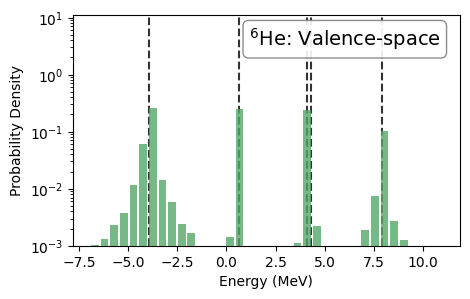

In [9]:
ncsm = False # True

# NCSM
if ncsm:
    target = "NN3NF"
    Zc = Nc = 0
    emax = e3max = 1
    filename_snt = int_file_path + f"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax{emax}_e2max{emax*2}.kshell.snt"
    fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
    #fn_3NF = None; target = "NN-only"
    target_parity = +1
    nuc = "2H"; Z = proton_number = N = neutron_number = 1; qrange = [0, 3]
    nuc = "3n"; Z = proton_number = 0; N = neutron_number = 3; qrange = [8, 9, 14]; target_parity = -1; size_Eshift = 0.0
    delta_t = - 0.1
else:
    target = "valence"
    fn_snt = int_file_path+"ckpot.snt"; Zc = Nc = 2
    nuc = "He6"; Z = 2; N = 4; qrange = [8, 11]
    target_parity = 1 
if ncsm:
    hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, 
                        verbose=False, emax_truncate=emax,
                        e3max=e3max, fn_3NF=fn_3NF)
else:
    hamil = Hamiltonian(fn_snt, Z, N)
    
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)

Hamil_mapped = 0 * H_1b_p
if Z-Zc > 0:
    Hamil_mapped += H_1b_p
    if Z-Zc > 1:
        Hamil_mapped += H_pp
if N-Nc > 0:
    Hamil_mapped += H_1b_n
    if N-Nc > 1:
        Hamil_mapped += H_nn

if (Z-Zc) * (N-Nc) > 0:
    Hamil_mapped += H_pn 

if ncsm:
    if fn_3NF is not None:
        hamil.set_mscheme_3NF()
        H_3b = hamil.mapping_3NF_Mscheme()
        Hamil_mapped += H_3b

Hamil_mapped = Hamil_mapped.simplify()
n_qubits_p = hamil.n_qubits_p
n_qubits_n = hamil.n_qubits_n
Nq = n_qubits_p + n_qubits_n

# Read Hamiltonian & M-scheme encoding
if ncsm:
    hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, 
                        verbose=False, emax_truncate=emax,
                        e3max=e3max, fn_3NF=fn_3NF)
else:
    hamil = Hamiltonian(fn_snt, Z, N)
    
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)

Hamil_mapped = 0 * H_1b_p
if Z-Zc > 0:
    Hamil_mapped += H_1b_p
    if Z-Zc > 1:
        Hamil_mapped += H_pp
if N-Nc > 0:
    Hamil_mapped += H_1b_n
    if N-Nc > 1:
        Hamil_mapped += H_nn

if (Z-Zc) * (N-Nc) > 0:
    Hamil_mapped += H_pn 

if ncsm:
    if fn_3NF is not None:
        hamil.set_mscheme_3NF()
        H_3b = hamil.mapping_3NF_Mscheme()
        Hamil_mapped += H_3b

Hamil_mapped = Hamil_mapped.simplify()
n_qubit_p = hamil.n_qubits_p
n_qubit_n = hamil.n_qubits_n
n_qubit = n_qubit_p + n_qubit_n
print("n_qubit:", n_qubit, "(p:", n_qubit_p, ", n:", n_qubit_n, ")")

# Brute force diagonalization for comparison: `Diagonalize_Hamiltonian` in src/nuqulib/diagonalization.py
obj_Diag = Diagonalize_Hamiltonian(Hamil_mapped, hamil, Z, N, target_parity, Zc, Nc)
basis = obj_Diag["basis"]
Hsub = obj_Diag["Hsub"]
Ens_exact = obj_Diag["evals"]

# State preparation
U_prep = QuantumCircuit(n_qubit)
for q in qrange:
    U_prep.x(q)

# Energy check
sim = AerSimulator(method='statevector', device=device_type)
psi = U_prep.remove_final_measurements(inplace=False)
psi.save_statevector()
tqc = transpile(psi, sim)
job = sim.run(tqc)
result = job.result()
psi_final = result.get_statevector(tqc)
E_expect = psi_final.expectation_value(Hamil_mapped).real 
print(f"Energy expectation value of the prepared state: {E_expect:.6f} MeV")

# Energy shift
Hamil_shifted = Hamil_mapped - size_Eshift * SparsePauliOp("I" * n_qubit)

# Construct QPE circuit
qc_QPE = circuit_my_QPE(n_ancilla, n_qubit, Hamil_shifted, U_prep, delta_t, trotter_order=trotter_order, trotter_steps=trotter_steps)
qc_sv = qc_QPE.remove_final_measurements(inplace=False)
qc_sv.save_statevector()

# Run Aer statevector simulator
print("Running QPE circuit with statevector simulator...")
sim = AerSimulator(method='statevector', device=device_type)
tqc = transpile(qc_sv, sim)
job = sim.run(tqc)
result = job.result()
psi_final = result.get_statevector(tqc)

# Get probabilities on ancilla register only
anc_idx = [qc_QPE.qubits.index(q) for q in qc_QPE.qregs[0]]
probs = psi_final.probabilities_dict(qargs=anc_idx)

list_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
summarized_probs = {} 
for bitstring_whole, p in list_probs:
    bitstring = bitstring_whole[:n_ancilla]
    if bitstring in summarized_probs:
        summarized_probs[bitstring] += p
    else:
        summarized_probs[bitstring] = p
list_probs = sorted(summarized_probs.items(), key=lambda x: x[1], reverse=True)

Energy_list = []
for idx, (bitstring, p) in enumerate(list_probs):
    energy = 2 * np.pi * int(bitstring[::-1], 2) / (-delta_t * (2**n_ancilla))
    energy += size_Eshift
    Energy_list.append((energy, p))
    if idx < 10:
        print(f"Bitstring: {bitstring}, Energy: {energy:.6f} MeV, Probability: {p:.6f}")
plot_spectrum(n_ancilla, delta_t, target, nuc, Energy_list, Ens_exact, save_fig=True)

One can see four peaks by QPE.
This seems the issue of resolution of QPE (governed by the number of ancilla qubits and Trotter steps),
but actually, the fourth state has no overlap with the initial state made by naive filling of the p3/2 orbital, and thus it is not obtained by QPE.

## Observable Dynamic Mode Decomposition (ODMD)

ODMD method is a quantum algorithm for simulating the eigen spectrum of quantum systems. It is based on the idea of dynamic mode decomposition (DMD), which is a data-driven method for analyzing the dynamics of complex systems such as fluid dynamics. ODMD extends DMD to quantum systems by using quantum circuits to represent the time evolution operator and the observables of interest.

Ref: Y. Shen et al., [Quantum 9, 1836 (2025)](https://doi.org/10.22331/q-2025-08-27-1836)

For the ODMD demonstration (and the subsequent QKrylov method), we adopt the HCB mapping of the nuclear Hamiltonian. Fermionic representations generally produce longer Pauli strings and thus higher computational cost.  
The time step for ODMD is set to \(1\times10^{-2}\), smaller than that used in QPE.


In [10]:
delta_t_ODMD = 0.1

## Specifying the target system and the Hamiltonian
ms = "sd"
idx = 1
Z = modelspace[ms]["Zcore"]
N = modelspace[ms]["Nrange"][idx]
A = Z + N
nuc = str(A) + element[Z]
adopted_ms = modelspace[ms]
fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
vZ = Z - Zcore
vN = N - Ncore
Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

## Setting up the qubits and Hamiltonian in the qubit representation
Nocc = (A - Acore) // 2
Nq = len(Dict_sps_to_qubits.keys())

h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
idx_min = np.argmin(evals)
Egs_exact = evals[idx_min]
gs_wf = evecs[:, idx_min] 
hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

sampler = AerSimulator(method="statevector", device=device_type)
ancilla_qubits = [0]
target_qubits = list(range(1, Nq+1))

dim_Hankel = 15
max_iterations = dim_Hankel + 10
np.random.seed(42)
params = np.array(Dict_Egs_pUCCD[nuc]["params"]) + np.random.randn(Nocc*(Nq-Nocc))
qc_ansatz = pair_ansatz_qiskit(params, Nq, Nocc, method="pUCCD", decent_order=True)
Ens_ODMD, lams_ODMD = ODMD(qc_ansatz, hamiltonian_op, delta_t_ODMD, max_iterations,
                           trotter_order, trotter_steps, sampler, ancilla_qubits, target_qubits,
                           dim_Hankel=dim_Hankel, tol_lambda=0.05)
print("Ens from ODMD:", "".join([f"{tmp:8.3f} " for tmp in np.sort(Ens_ODMD)]))
print("Evals (DOCI): ",  "".join([f"{tmp:8.3f} " for tmp in np.sort(evals[:10])]))

  4%|▍         | 1/24 [00:04<01:50,  4.78s/it]

overlap @  1: (0.033461719384409394+0.6889358738206929j)


  8%|▊         | 2/24 [00:09<01:47,  4.89s/it]

overlap @  2: (-0.06176471050011495-0.058286011449945885j)


 12%|█▎        | 3/24 [00:14<01:44,  4.96s/it]

...

overlap @ 22: (0.2167961908769469+0.4476300078996506j)


 96%|█████████▌| 23/24 [01:53<00:04,  4.96s/it]

overlap @ 23: (-0.715747615133275+0.1582690649338897j)


100%|██████████| 24/24 [01:58<00:00,  4.94s/it]

overlap @ 24: (-0.04702082617996084-0.5040734197024196j)
Max iteration:    25 trotter_steps:    10 delta_t:   0.10000000  tol for lambda = 5.00e-02
Check |AX - Y| 4.708484678790688e-15
Ens from ODMD:  -23.155  -19.606  -16.237   -9.186   -6.917   -4.438    6.906 
Evals (DOCI):   -23.146  -20.357  -19.536  -18.134  -16.733  -15.865   -9.236   -8.231   -3.202    6.907 


## Quantum Krylov subspace method (QKrylov)

QKrylov is a quantum algorithm for finding eigenvalues and eigenvectors of a Hamiltonian, based on the idea of Krylov subspace methods, which are often used in classical computing for solving quantum many-body problems.

We use the same pUCCD ansatz as in the VQE example as the initial state, with slight parameter perturbations so that the initial state is not exactly the ground state.

In [11]:
delta_t_QKrylov = 0.2

In [12]:
## Specifying the target system and the Hamiltonian
ms = "sd"
idx = 1
Z = modelspace[ms]["Zcore"]
N = modelspace[ms]["Nrange"][idx]
A = Z + N
nuc = str(A) + element[Z]
adopted_ms = modelspace[ms]
fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
vZ = Z - Zcore
vN = N - Ncore
Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

## Setting up the qubits and Hamiltonian in the qubit representation
Nocc = (A - Acore) // 2
Nq = len(Dict_sps_to_qubits.keys())

h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
idx_min = np.argmin(evals)
Egs_exact = evals[idx_min]
gs_wf = evecs[:, idx_min] 
hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

In [13]:
print("Target nucleus:", nuc)
sampler = AerSimulator(method="statevector", device=device_type)
ancilla_qubits = [0]
target_qubits = list(range(1, Nq+1))

np.random.seed(42)
init_params = np.array(Dict_Egs_pUCCD[nuc]["params"]) + 0.5 * np.random.randn(Nocc*(Nq-Nocc))
qc_ansatz = pair_ansatz_qiskit(init_params, Nq, Nocc, method="pUCCD", decent_order=True)   

res_QKrylov = QuantumKrylov(qc_ansatz, hamiltonian_op, sampler,
                            ancilla_qubits, target_qubits,
                            delta_t_QKrylov,
                            trotter_rank=trotter_order, trotter_steps=trotter_steps, max_iterations=10,
                            using_statevector=True, verbose=True)

Target nucleus: 20O
num of Hamil term:  52


  0%|          | 0/10 [00:00<?, ?it/s]

iteration:  0


 10%|█         | 1/10 [00:00<00:05,  1.63it/s]

H[diag=0] = (-20.676941158769118+0j)
eigs of N:  [1.] cond 1.0 r: 1
w: [-20.67694116]

iteration:  1
H[diag=1] = (-20.67694838181904+0j)


...

H[off-diag=7,0] = (-10.300619098820759+15.633473112868248j)
eigs of N:  [2.57353058e-04 3.82487254e-03 1.78145191e-02 8.53476453e-02
 2.08011966e-01 2.57608121e-01 9.11174220e-01 6.51596130e+00] cond 25319.152418421098 r: 8
w: [-23.14047537 -19.55079267 -16.63902133 -10.07208354  -8.8748184
  -6.8534923   -4.35030171   4.65205825]

iteration:  8
H[diag=8] = (-20.699850266229372+0j)
H[off-diag=8,7] = (2.1930284500575565-17.943267733269533j)
H[off-diag=8,6] = (19.30317620099237+3.382748970009924j)
H[off-diag=8,5] = (-4.842544395117074+16.85302564227766j)
H[off-diag=8,4] = (-18.27242283893653-5.479975955723866j)
H[off-diag=8,3] = (7.6926818111291135-16.65464329212933j)
H[off-diag=8,2] = (16.740768944460264+8.333558296579078j)
H[off-diag=8,1] = (-10.246663688287235+15.677434681684693j)


 90%|█████████ | 9/10 [15:10<02:34, 154.62s/it]

H[off-diag=8,0] = (-15.109465211543075-10.926002652486652j)
eigs of N:  [1.12595436e-04 2.17201043e-03 6.30860304e-03 2.96653512e-02
 1.42056062e-01 2.16150752e-01 3.12104382e-01 9.74323287e-01
 7.31710696e+00] cond 64985.822023990666 r: 9
w: [-23.14411923 -19.67642666 -16.98504284 -15.92041457  -9.15903557
  -7.44357264  -6.08054995  -4.00775079   6.35947532]

iteration:  9
H[diag=9] = (-20.678537201449064+0j)
H[off-diag=9,8] = (2.1577973905367687-17.94668233916482j)
H[off-diag=9,7] = (19.30057784051383+3.321660233272001j)
H[off-diag=9,6] = (-4.76452566582552+16.857849492840483j)
H[off-diag=9,5] = (-18.28743123937572-5.382717248167006j)
H[off-diag=9,4] = (7.602063214305546-16.68043845934772j)
H[off-diag=9,3] = (16.77120819476197+8.227545458889546j)
H[off-diag=9,2] = (-10.16022163186128+15.725594885987013j)
H[off-diag=9,1] = (-15.15218513043419-10.826272986585822j)


100%|██████████| 10/10 [19:05<00:00, 114.57s/it]

H[off-diag=9,0] = (12.979589513271918-14.670549829784685j)
eigs of N:  [3.27977447e-05 1.35671297e-03 3.52451501e-03 1.25690970e-02
 5.21222287e-02 1.60770205e-01 2.24595057e-01 3.89675016e-01
 1.02451665e+00 8.13083772e+00] cond 247908.43994162613 r: 10
w: [-23.1454885  -19.78494149 -17.91920315 -16.45507786  -9.63494462
  -8.93270485  -7.08600527  -5.34704225  -3.75199942   6.66714482]



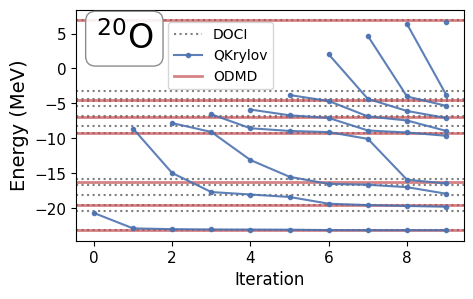

In [14]:
En_history = res_QKrylov[2]
Ens = []
num_states = 10
for iter in range(len(En_history)):
    tmp = [None for _ in range(num_states)]
    for i in range(len(En_history[iter])):
        tmp[i] = En_history[iter][i]
    Ens.append(tmp)

fig = plt.figure(figsize=(5,3))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Energy (MeV)", fontsize=14)

evals = np.sort(evals)
for (n, eval) in enumerate(evals):
    ax.axhline(eval, color="gray", linestyle="dotted", label="DOCI" if n==0 else None)

for i in range(num_states):
    ax.plot(range(len(En_history)), 
            [Ens[iter][i] for iter in range(len(En_history))], 
            marker = "o", markersize=3, 
            color = cols[2],
            alpha=0.9,
            zorder=100, label="QKrylov" if i==0 else None)

for i in range(len(Ens_ODMD)):
    ax.axhline(Ens_ODMD[i], color=cols[1], alpha=0.7, lw = 2, label="ODMD" if i==0 else None)
ax.tick_params(axis='both', labelsize=11)
ax.text(0.05, 0.95, cnuc(nuc), ha="left", va="top", transform=ax.transAxes, fontsize=24, 
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
ax.legend(bbox_to_anchor=(0.22, 0.8), loc="center left")
plt.savefig("QKrylov_ODMD_Ens_" + nuc + ".pdf", bbox_inches="tight", pad_inches=0.03)
plt.show()
plt.close()